# 08. Regression Metrics, Residuals, and Operational Error Costs

A regression model is not good simply because one summary number looks small. In decision settings, the meaning of forecast error depends on *where* the model fails, *how often* it misses important regimes, and *what downstream action* the prediction is meant to support. A staffing forecast that looks strong on average may still be operationally dangerous if it underpredicts release-week surges. Conversely, a slightly conservative forecast may look worse on RMSE while producing better real-world decisions.

This notebook studies regression evaluation through that wider lens. We begin with standard predictive metrics such as MAE, RMSE, median absolute error, WAPE, sMAPE, and MAPE. We then move to residual diagnostics, because a metric average can hide structured failure by regime, scale, or time period. Finally, we translate forecast error into a weighted staffing cost where underprediction is more expensive than overprediction and show how that changes the preferred forecasting strategy.

The intellectual theme follows several classic ideas. Hyndman and Koehler (2006) review the strengths and weaknesses of common forecast-accuracy measures. Chai and Draxler (2014) and Hodson (2022) clarify why RMSE and MAE answer different questions rather than forming a simple either-or contest. Tofallis (2015) highlights why percentage-error measures such as MAPE can behave badly. And Koenker and Bassett (1978) provide the foundation for quantile-style loss functions that are useful when under- and over-prediction carry different costs.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain the practical differences among MAE, RMSE, median absolute error, WAPE, sMAPE, and MAPE.
2. Diagnose residual structure rather than relying only on one aggregate evaluation number.
3. Identify when percentage-based error measures become unstable or misleading.
4. Translate prediction error into an asymmetric operational cost function.
5. Explain why a model optimized for ordinary mean error may differ from one aligned to a high-cost underprediction environment.


## 1. Why Metric Choice Is a Modeling Decision

Let the residual for observation $i$ be

$$
e_i = y_i - \hat{y}_i.
$$

Several standard regression metrics summarize the residuals in different ways:

$$
\operatorname{MAE} = \frac{1}{n}\sum_{i=1}^n |e_i|,
$$

$$
\operatorname{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^n e_i^2},
$$

$$
\operatorname{WAPE} = 100 	imes \frac{\sum_{i=1}^n |e_i|}{\sum_{i=1}^n |y_i|},
$$

$$
\operatorname{sMAPE} = 100 	imes \frac{1}{n} \sum_{i=1}^n \frac{2|e_i|}{|y_i| + |\hat{y}_i|}.
$$

These formulas may look similar, but they answer meaningfully different questions.

| Metric | What it emphasizes | Good use case | Main caution |
|---|---|---|---|
| `MAE` | Typical absolute mistake | When average error magnitude matters directly | Does not heavily penalize rare large misses |
| `RMSE` | Large errors and tail risk | When spikes and outages are especially costly | Can be dominated by a small number of extreme misses |
| `MedianAE` | Typical robust miss | When outliers are present and you want stability | Can understate tail risk |
| `WAPE` | Scale-free total error share | Comparing performance across different scales | Still aggregates over all days and can hide regimes |
| `sMAPE` | Relative error with symmetric denominator | Scale-free comparison when plain percentages are unstable | Less intuitive than MAE or RMSE |
| `MAPE` | Percentage error relative to actuals | Sometimes useful for strictly positive, stable-scale targets | Becomes unstable when actual values are very small |

The key lesson is simple. A metric encodes priorities. If large misses are disproportionately harmful, RMSE can be informative. If robustness matters, MAE or median absolute error may be better. If underprediction is especially costly, even MAE may be the wrong target and an asymmetric loss may be more appropriate.


In [1]:
# Section focus: 1. Why Metric Choice Is a Modeling Decision.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")

sns.set_theme(style='whitegrid', palette='crest')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

rng = np.random.default_rng(42)


def smape(y_true, y_pred):
    """Carry out the smape step used in the 08. Regression Metrics, Residuals, and Operational Error Costs workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the smape calculation.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    numer = 2 * np.abs(y_true - y_pred)
    return 100 * np.mean(np.divide(numer, denom, out=np.zeros_like(numer, dtype=float), where=denom > 0))


def mape(y_true, y_pred):
    """Carry out the mape step used in the 08. Regression Metrics, Residuals, and Operational Error Costs workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the mape calculation.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100 * np.mean(np.abs((y_true - y_pred) / y_true))


def wape(y_true, y_pred):
    """Carry out the wape step used in the 08. Regression Metrics, Residuals, and Operational Error Costs workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the wape calculation.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100 * np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


def pinball_loss(y_true, y_pred, alpha):
    """Carry out the pinball loss step used in the 08. Regression Metrics, Residuals, and Operational Error Costs workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    alpha : object
        Regularization, smoothing, or significance parameter used by the calculation.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the pinball loss calculation.
    """
    err = np.asarray(y_true) - np.asarray(y_pred)
    return np.mean(np.maximum(alpha * err, (alpha - 1) * err))


def evaluate_regression(y_true, y_pred, alpha_for_pinball=0.80):
    """Evaluate regression for the 08. Regression Metrics, Residuals, and Operational Error Costs decision workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    alpha_for_pinball : object
        The alpha for pinball setting that controls the regression calculation in this notebook.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    abs_err = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred),
        'median_ae': median_absolute_error(y_true, y_pred),
        'wape': wape(y_true, y_pred),
        'smape': smape(y_true, y_pred),
        'mape': mape(y_true, y_pred),
        'p90_abs_error': np.quantile(abs_err, 0.90),
        'r_squared': r2_score(y_true, y_pred),
        'pinball_0p80': pinball_loss(y_true, y_pred, alpha_for_pinball),
    }


def operational_cost(y_true, y_pred, under_cost=9.0, over_cost=2.5):
    """Carry out the operational cost step used in the 08. Regression Metrics, Residuals, and Operational Error Costs workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    under_cost : object
        Cost value used to translate model errors into operational consequences.
    over_cost : object
        Cost value used to translate model errors into operational consequences.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    err = np.asarray(y_true) - np.asarray(y_pred)
    under = np.clip(err, a_min=0, a_max=None)
    over = np.clip(-err, a_min=0, a_max=None)
    return {
        'under_units': under.sum(),
        'over_units': over.sum(),
        'under_cost_component': under_cost * under.sum(),
        'over_cost_component': over_cost * over.sum(),
        'weighted_cost': under_cost * under.sum() + over_cost * over.sum(),
        'underprediction_rate': np.mean(err > 0),
    }


## 2. Synthetic Staffing-Forecast Dataset

We will work with a daily forecasting problem for **next-day support-ticket demand**. The variables are chosen to feel operational rather than abstract:

- `promo_intensity`: marketing-driven demand pressure,
- `release_shock`: product-release periods that increase instability,
- `backlog_ratio`: unresolved work carried into the next day,
- `critical_incidents`: acute system problems,
- `self_service_uptime`: whether self-service channels absorb demand,
- `avg_handle_time`: a proxy for case complexity,
- `active_accounts`: scale of the customer base,
- seasonal and calendar features such as weekday, year-cycle, quarter-end, and holiday windows.

The data-generating process is deliberately imperfect for a linear model. It includes regime changes, interactions, and heteroskedasticity: when releases and backlog spikes happen together, both mean demand and forecast uncertainty rise. We also include a handful of very low-volume holiday days so that percentage-based metrics have a chance to misbehave.


,split,rows,mean_tickets,std_tickets,release_share,holiday_share
0,Train,378,135.680,30.527,0.074,0.037
1,Validation,81,136.689,38.435,0.086,0.062
2,Test,81,141.264,32.113,0.086,0.123


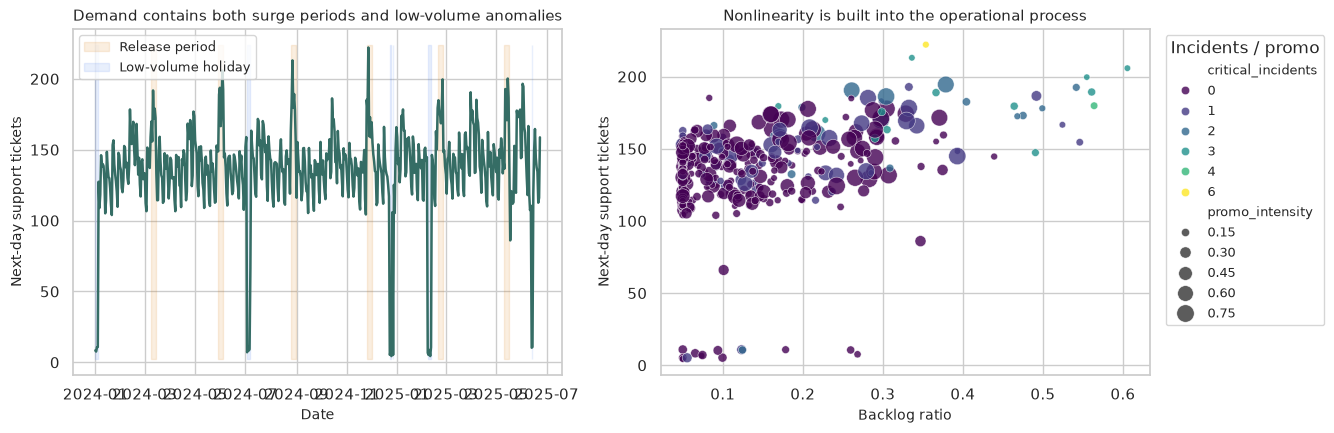

In [2]:

# Daily synthetic operations environment.
dates = pd.date_range('2024-01-01', periods=540, freq='D')
df = pd.DataFrame({'date': dates})
df['day_index'] = np.arange(len(df))
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['weekend'] = (df['day_of_week'] >= 5).astype(int)
df['quarter_end'] = df['date'].dt.is_quarter_end.astype(int)
df['day_of_year'] = df['date'].dt.dayofyear

df['sin_week'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['cos_week'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['sin_year'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['cos_year'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)

# Demand-driving promotional pulses.
campaign_centers = np.array([45, 118, 201, 287, 374, 458, 515])
promo = 0.08 + 0.08 * rng.random(len(df))
for c in campaign_centers:
    promo += 0.62 * np.exp(-((df['day_index'] - c) ** 2) / (2 * 7.5 ** 2))
df['promo_intensity'] = np.clip(promo, 0, 1)

# Release weeks create acute demand bursts.
release_centers = np.array([70, 152, 240, 332, 418, 498])
release = np.zeros(len(df))
for c in release_centers:
    release += np.exp(-((df['day_index'] - c) ** 2) / (2 * 3.2 ** 2))
df['release_shock'] = (release > 0.55).astype(int)

# Low-volume holiday windows are distributed across train, validation, and test periods.
holiday_window = np.zeros(len(df), dtype=int)
for center in [1, 186, 359, 405, 505, 528]:
    holiday_window |= (np.abs(df['day_index'] - center) <= 2).astype(int)
df['holiday_window'] = holiday_window.astype(int)

# Scale, reliability, and backlog dynamics.
df['active_accounts'] = (
    7_500
    + 2.4 * df['day_index']
    + 180 * df['sin_year']
    + rng.normal(0, 55, len(df))
)

base_uptime = 0.992 - 0.014 * df['release_shock'] - 0.004 * (df['promo_intensity'] > 0.65)
df['self_service_uptime'] = np.clip(base_uptime + rng.normal(0, 0.004, len(df)), 0.955, 0.999)

incident_rate = 0.20 + 1.15 * df['release_shock'] + 0.60 * (df['self_service_uptime'] < 0.980) + 0.35 * (df['promo_intensity'] > 0.6)
df['critical_incidents'] = rng.poisson(np.clip(incident_rate, 0.05, None))

backlog = np.zeros(len(df))
backlog[0] = 0.32
for t in range(1, len(df)):
    backlog[t] = (
        0.72 * backlog[t - 1]
        + 0.09 * df.loc[t, 'release_shock']
        + 0.06 * (df.loc[t, 'promo_intensity'] > 0.55)
        + 0.025 * df.loc[t, 'critical_incidents']
        + 0.028 * df.loc[t, 'weekend']
        + rng.normal(0, 0.045)
    )
df['backlog_ratio'] = np.clip(backlog, 0.05, 1.15)

df['avg_handle_time'] = (
    18.5
    + 1.8 * df['release_shock']
    + 1.2 * df['critical_incidents']
    + 12 * (0.985 - df['self_service_uptime']).clip(lower=0)
    + 4.0 * df['backlog_ratio']
    + rng.normal(0, 1.0, len(df))
)

weekday_effect = {0: 14, 1: 8, 2: 4, 3: 1, 4: -5, 5: -18, 6: -24}
base_tickets = (
    45
    + df['day_of_week'].map(weekday_effect)
    + 0.0085 * df['active_accounts']
    + 21 * df['promo_intensity']
    + 16 * df['release_shock']
    + 22 * df['backlog_ratio']
    + 3.8 * df['critical_incidents']
    + 0.85 * df['avg_handle_time']
    + 95 * (0.992 - df['self_service_uptime'])
    + 8 * df['quarter_end']
    - 40 * df['holiday_window']
)

base_tickets += 15 * ((df['backlog_ratio'] > 0.68) & (df['critical_incidents'] >= 2)).astype(int)
base_tickets += 12 * ((df['promo_intensity'] > 0.65) & (df['weekend'] == 0)).astype(int)
base_tickets += 10 * ((df['release_shock'] == 1) & (df['self_service_uptime'] < 0.980)).astype(int)

sigma = (
    4.0
    + 2.5 * df['promo_intensity']
    + 4.5 * df['release_shock']
    + 4.0 * (df['backlog_ratio'] > 0.70).astype(int)
    + 1.0 * df['critical_incidents']
)

noise = rng.normal(0, sigma)
tickets = base_tickets + noise

low_volume_days = (df['holiday_window'] == 1) & (df['release_shock'] == 0) & (df['promo_intensity'] < 0.25)
tickets = np.where(low_volume_days, 4 + 8 * rng.random(len(df)), tickets)

df['tickets_next_day'] = np.clip(np.round(tickets, 1), 2.0, None)

df['regime'] = np.select(
    [df['release_shock'] == 1, low_volume_days, df['promo_intensity'] > 0.60],
    ['Release period', 'Low-volume holiday', 'Promotion surge'],
    default='Routine operations'
)

split_idx_1 = int(len(df) * 0.70)
split_idx_2 = int(len(df) * 0.85)
df['split'] = np.where(df.index < split_idx_1, 'Train', np.where(df.index < split_idx_2, 'Validation', 'Test'))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))

sns.lineplot(data=df, x='date', y='tickets_next_day', ax=axes[0], color='#356D65', linewidth=1.8)
axes[0].fill_between(df['date'], df['tickets_next_day'].min() - 2, df['tickets_next_day'].max() + 2,
                     where=df['release_shock'].astype(bool), color='#d97706', alpha=0.12, label='Release period')
axes[0].fill_between(df['date'], df['tickets_next_day'].min() - 2, df['tickets_next_day'].max() + 2,
                     where=low_volume_days.astype(bool), color='#2563eb', alpha=0.10, label='Low-volume holiday')
axes[0].set_title('Demand contains both surge periods and low-volume anomalies')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Next-day support tickets')
axes[0].legend(loc='upper left')

sns.scatterplot(
    data=df.sample(400, random_state=0),
    x='backlog_ratio',
    y='tickets_next_day',
    hue='critical_incidents',
    size='promo_intensity',
    sizes=(20, 160),
    palette='viridis',
    alpha=0.80,
    ax=axes[1],
)
axes[1].set_title('Nonlinearity is built into the operational process')
axes[1].set_xlabel('Backlog ratio')
axes[1].set_ylabel('Next-day support tickets')
axes[1].legend(title='Incidents / promo', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

summary_table = pd.DataFrame(
    [
        {'split': name, 'rows': len(frame), 'mean_tickets': frame['tickets_next_day'].mean(), 'std_tickets': frame['tickets_next_day'].std(), 'release_share': frame['release_shock'].mean(), 'holiday_share': frame['holiday_window'].mean()}
        for name, frame in df.groupby('split', sort=False)
    ]
)
summary_table


Use the Synthetic Staffing-Forecast Dataset output to decide what the analysis should do next. The practical signal is the one that changes what the analyst does next.


### Discussion of the Data-Generating Process

The synthetic series is intentionally awkward in the way real operational data often is. There are smooth seasonal patterns, but there are also abrupt release periods, demand surges, and a small number of low-volume holiday days. Those low-volume days matter because they create exactly the condition under which percentage-based metrics can look dramatic even when the absolute forecast miss is not operationally large.

Just as importantly, the variance is not constant. Forecast uncertainty expands during release periods, heavy backlog regimes, and incident clusters. That means a model can look decent in average-error terms while still failing systematically in the most expensive regimes.


## 3. Competing Forecasting Strategies

We will compare five forecasting approaches:

1. a `Mean baseline` that predicts the training average,
2. a `Ridge` model as a strong linear baseline,
3. a `Random forest` for nonlinear averaging,
4. a `HistGB (mean)` model that targets the conditional mean with boosted trees,
5. a `GB quantile (0.78)` model that targets a higher conditional quantile.

The last model is included for a reason that goes beyond predictive accuracy. Suppose understaffing is much more expensive than overstaffing. If the underprediction cost is $c_u$ and the overprediction cost is $c_o$, then a natural decision loss is

$$
L(y, \hat{y}) = c_u (y - \hat{y})_+ + c_o (\hat{y} - y)_+,
$$

where $(a)_+ = \max(a, 0)$. With this loss, the optimal target is not the conditional mean but a higher conditional quantile. That is the connection to regression quantiles in the sense of Koenker and Bassett (1978).


In [3]:
# Section focus: 3. Competing Forecasting Strategies.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


feature_cols = [
    'promo_intensity',
    'release_shock',
    'backlog_ratio',
    'critical_incidents',
    'self_service_uptime',
    'avg_handle_time',
    'active_accounts',
    'weekend',
    'quarter_end',
    'holiday_window',
    'sin_week',
    'cos_week',
    'sin_year',
    'cos_year',
]

target_col = 'tickets_next_day'

train = df[df['split'] == 'Train'].copy()
validation = df[df['split'] == 'Validation'].copy()
test = df[df['split'] == 'Test'].copy()

X_train, y_train = train[feature_cols], train[target_col]
X_validation, y_validation = validation[feature_cols], validation[target_col]
X_test, y_test = test[feature_cols], test[target_col]

under_cost = 9.0
over_cost = 2.5
alpha_cost = under_cost / (under_cost + over_cost)

models = {
    'Mean baseline': DummyRegressor(strategy='mean'),
    'Ridge': Pipeline([('scale', StandardScaler()), ('ridge', Ridge(alpha=1.2))]),
    'Random forest': RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=4,
        random_state=0,
        n_jobs=-1,
    ),
    'HistGB (mean)': HistGradientBoostingRegressor(
        max_depth=5,
        learning_rate=0.06,
        max_iter=350,
        min_samples_leaf=18,
        l2_regularization=0.10,
        random_state=0,
    ),
    'GB quantile (0.78)': GradientBoostingRegressor(
        loss='quantile',
        alpha=alpha_cost,
        n_estimators=500,
        learning_rate=0.04,
        max_depth=3,
        subsample=0.90,
        random_state=0,
    ),
}

predictions = {}
metric_rows = []

for model_name, model in models.items():
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    predictions[model_name] = {
        'validation': fitted.predict(X_validation),
        'test': fitted.predict(X_test),
        'fitted_model': fitted,
    }
    for split_name, y_true, y_pred in [
        ('Validation', y_validation, predictions[model_name]['validation']),
        ('Test', y_test, predictions[model_name]['test']),
    ]:
        row = {'model': model_name, 'split': split_name}
        row.update(evaluate_regression(y_true, y_pred, alpha_for_pinball=alpha_cost))
        metric_rows.append(row)

validation_buffer = float(np.quantile(y_validation - predictions['HistGB (mean)']['validation'], alpha_cost))
buffered_mean_test = predictions['HistGB (mean)']['test'] + validation_buffer
buffered_mean_validation = predictions['HistGB (mean)']['validation'] + validation_buffer

metric_table = pd.DataFrame(metric_rows)
metric_table_test = metric_table.query("split == 'Test'").copy()
metric_table_test = metric_table_test.sort_values('rmse').reset_index(drop=True)
metric_table_test


,model,split,rmse,mae,median_ae,wape,smape,mape,p90_abs_error,r_squared,pinball_0p80
0,GB quantile (0.78),Test,14.925,8.367,6.341,5.923,8.484,23.549,11.992,0.781,3.969
1,HistGB (mean),Test,23.007,13.138,5.839,9.300,11.754,32.211,37.325,0.480,5.511
2,Ridge,Test,25.322,13.894,6.271,9.836,15.747,13.077,32.052,0.370,8.479
3,Random forest,Test,28.184,15.336,8.360,10.856,18.530,15.983,27.956,0.220,11.255
4,Mean baseline,Test,32.399,23.180,17.680,16.409,18.174,42.804,49.520,-0.031,13.168


In Competing Forecasting Strategies, the point of the output is practical. Use it to sharpen the model choice, diagnostic plan, threshold, or guardrail.


,model,rmse,mae,median_ae,wape,smape,mape,p90_abs_error,pinball_0p80
0,GB quantile (0.78),1.000,1.000,3.000,1.000,1.000,3.000,1.000,1.000
1,HistGB (mean),2.000,2.000,1.000,2.000,2.000,4.000,4.000,2.000
2,Ridge,3.000,3.000,2.000,3.000,3.000,1.000,3.000,3.000
3,Random forest,4.000,4.000,4.000,4.000,5.000,2.000,2.000,4.000
4,Mean baseline,5.000,5.000,5.000,5.000,4.000,5.000,5.000,5.000


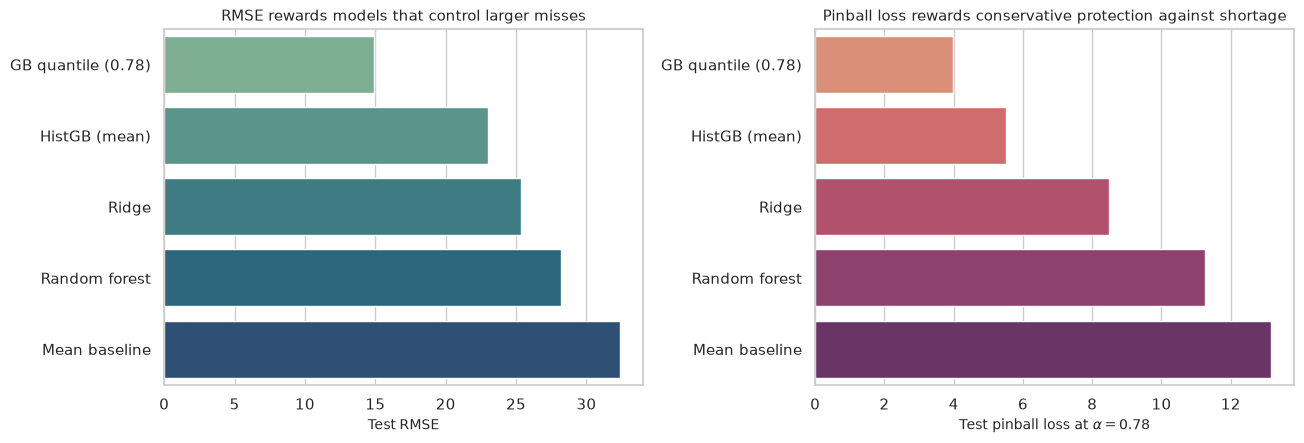

In [4]:

plot_metrics = metric_table_test[['model', 'rmse', 'mae', 'wape', 'pinball_0p80']].copy()
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6))

rmse_order = plot_metrics.sort_values('rmse')['model']
sns.barplot(data=plot_metrics, y='model', x='rmse', order=rmse_order, palette='crest', ax=axes[0])
axes[0].set_title('RMSE rewards models that control larger misses')
axes[0].set_xlabel('Test RMSE')
axes[0].set_ylabel('')

pin_order = plot_metrics.sort_values('pinball_0p80')['model']
sns.barplot(data=plot_metrics, y='model', x='pinball_0p80', order=pin_order, palette='flare', ax=axes[1])
axes[1].set_title('Pinball loss rewards conservative protection against shortage')
axes[1].set_xlabel(r'Test pinball loss at $\alpha=0.78$')
axes[1].set_ylabel('')

plt.tight_layout()

metric_rank = metric_table_test[['model', 'rmse', 'mae', 'median_ae', 'wape', 'smape', 'mape', 'p90_abs_error', 'pinball_0p80']].copy()
for col in metric_rank.columns[1:]:
    metric_rank[col] = metric_rank[col].rank(method='min')
metric_rank


Competing Forecasting Strategies gives a checkpoint for the decision workflow. The analyst should leave with a clearer model, diagnostic, threshold, or guardrail question.


### Discussion of the Metric Table

The comparison now makes the main point nicely. Different models can look strong for different reasons, and the ranking shifts once the metric changes. A flexible nonlinear model may dominate RMSE and MAE, while a more conservative strategy can become attractive under an asymmetric loss.

The stronger quantile-boosting configuration is especially useful pedagogically here. It shows that an asymmetric objective can be practical rather than only theoretical; it can produce a forecast that competes well on ordinary predictive metrics while also moving in the direction the staffing decision problem prefers.


## 4. Residual Diagnostics: Where Does the Model Fail?

Aggregate scores are a starting point, not the endpoint. Two models with similar MAE can fail in very different ways. Residual diagnostics help us answer questions such as:

- Are errors growing with predicted volume?
- Is the model systematically underpredicting release periods?
- Are low-volume days distorting percentage-based metrics?
- Does error structure change over time?

We focus first on the `HistGB (mean)` model because it will usually be among the strongest mean-oriented predictors in this notebook.


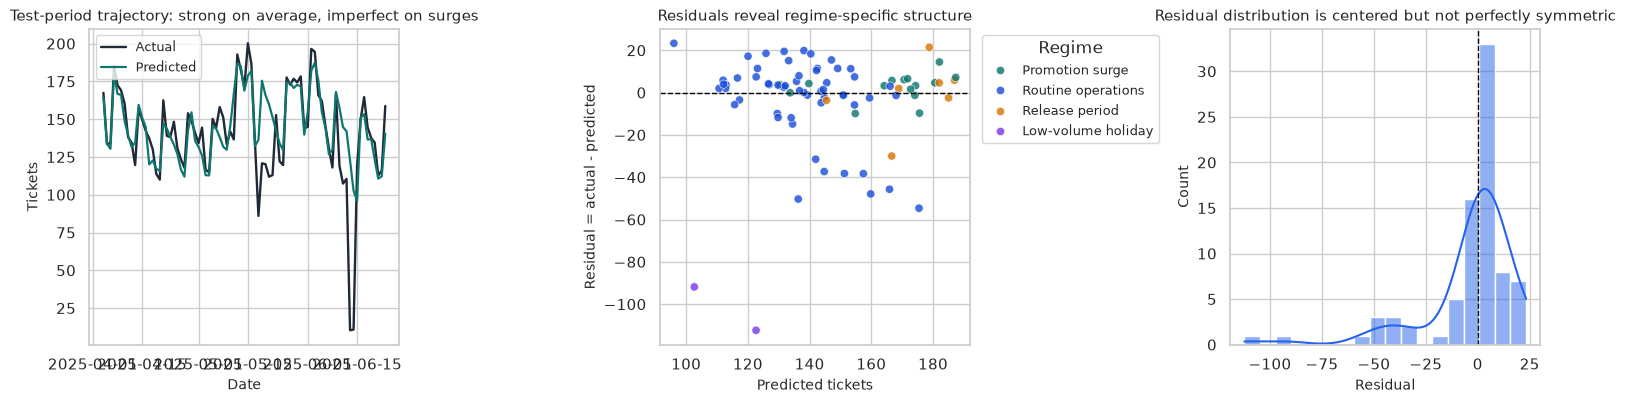

In [5]:
# Section focus: 4. Residual Diagnostics: Where Does the Model Fail?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


mean_model_name = 'HistGB (mean)'
mean_pred_test = predictions[mean_model_name]['test']

diagnostics = test[['date', 'regime', 'release_shock', 'holiday_window', 'promo_intensity', 'tickets_next_day']].copy()
diagnostics['pred_mean'] = mean_pred_test
diagnostics['residual_mean'] = diagnostics['tickets_next_day'] - diagnostics['pred_mean']
diagnostics['abs_error_mean'] = diagnostics['residual_mean'].abs()
diagnostics['ape_mean'] = 100 * diagnostics['abs_error_mean'] / diagnostics['tickets_next_day']
diagnostics['volume_bucket'] = pd.qcut(
    diagnostics['tickets_next_day'],
    q=4,
    labels=['Low volume', 'Moderate', 'High', 'Very high'],
)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))

sns.lineplot(data=diagnostics, x='date', y='tickets_next_day', label='Actual', color='#1f2937', linewidth=1.7, ax=axes[0])
sns.lineplot(data=diagnostics, x='date', y='pred_mean', label='Predicted', color='#0f766e', linewidth=1.6, ax=axes[0])
axes[0].set_title('Test-period trajectory: strong on average, imperfect on surges')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Tickets')
axes[0].legend(loc='upper left')

sns.scatterplot(
    data=diagnostics,
    x='pred_mean',
    y='residual_mean',
    hue='regime',
    palette=['#0f766e', '#1d4ed8', '#d97706', '#7c3aed'],
    alpha=0.82,
    ax=axes[1],
)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residuals reveal regime-specific structure')
axes[1].set_xlabel('Predicted tickets')
axes[1].set_ylabel('Residual = actual - predicted')
axes[1].legend(title='Regime', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.histplot(diagnostics['residual_mean'], bins=18, kde=True, color='#2563eb', ax=axes[2])
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Residual distribution is centered but not perfectly symmetric')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')

plt.tight_layout()


The Residual Diagnostics: Where Does the Model Fail? result matters when it changes the next move. The goal is to identify evidence that changes a real workflow choice.


In [6]:

regime_summary = (
    diagnostics
    .groupby('regime', as_index=False)
    .agg(
        rows=('tickets_next_day', 'size'),
        mean_actual=('tickets_next_day', 'mean'),
        mean_prediction=('pred_mean', 'mean'),
        mean_error=('residual_mean', 'mean'),
        mae=('abs_error_mean', 'mean'),
        wape=('abs_error_mean', lambda s: 100 * s.sum() / diagnostics.loc[s.index, 'tickets_next_day'].sum()),
        underprediction_rate=('residual_mean', lambda s: np.mean(s > 0)),
    )
    .sort_values('mae', ascending=False)
)
regime_summary


,regime,rows,mean_actual,mean_prediction,mean_error,mae,wape,underprediction_rate
0,Low-volume holiday,2,10.550,112.639,-102.089,102.089,967.673,0.000
3,Routine operations,57,134.944,137.333,-2.389,12.428,9.210,0.614
2,Release period,7,173.043,173.387,-0.344,9.998,5.778,0.571
1,Promotion surge,15,167.880,165.241,2.639,5.440,3.240,0.733


This result sits between model performance and the operating policy. The useful reading is which metric would change the action in Residual Diagnostics: Where Does the Model Fail?. Metric disagreement should force the analyst to state the operating priority.


,volume_bucket,rows,mae,median_ape,mean_ape
0,Low volume,21,30.218,19.522,110.873
1,Moderate,20,6.229,2.831,4.665
2,High,20,8.700,5.042,5.731
3,Very high,20,6.550,2.765,3.643


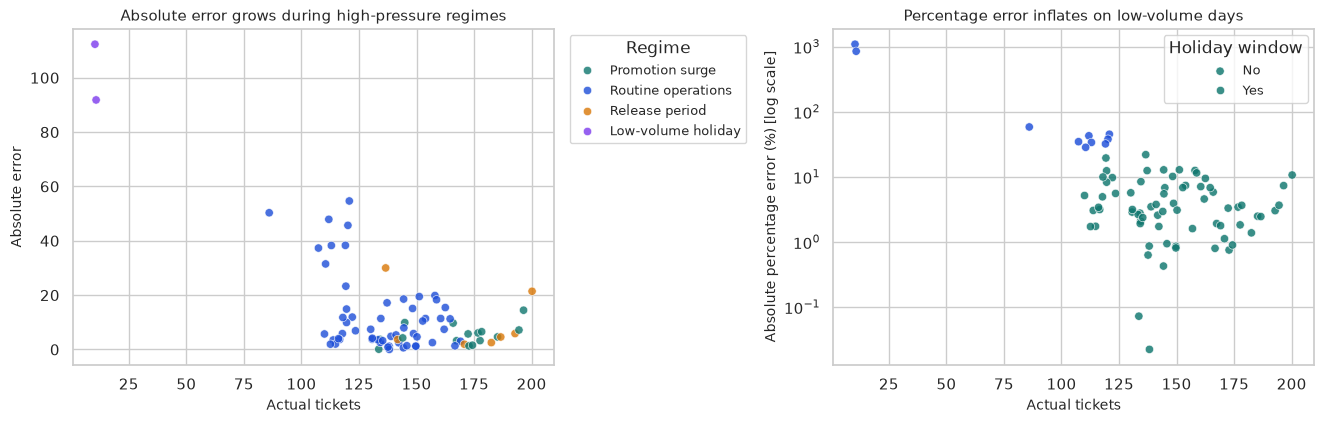

In [7]:
# Section focus: 4. Residual Diagnostics: Where Does the Model Fail?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.4))

sns.scatterplot(
    data=diagnostics,
    x='tickets_next_day',
    y='abs_error_mean',
    hue='regime',
    palette=['#0f766e', '#1d4ed8', '#d97706', '#7c3aed'],
    alpha=0.80,
    ax=axes[0],
)
axes[0].set_title('Absolute error grows during high-pressure regimes')
axes[0].set_xlabel('Actual tickets')
axes[0].set_ylabel('Absolute error')
axes[0].legend(title='Regime', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.scatterplot(
    data=diagnostics,
    x='tickets_next_day',
    y='ape_mean',
    hue='holiday_window',
    palette=['#0f766e', '#1d4ed8'],
    alpha=0.82,
    ax=axes[1],
)
axes[1].set_title('Percentage error inflates on low-volume days')
axes[1].set_xlabel('Actual tickets')
axes[1].set_ylabel('Absolute percentage error (%) [log scale]')
axes[1].set_yscale('log')
axes[1].legend(title='Holiday window', labels=['No', 'Yes'], loc='upper right')

plt.tight_layout()

volume_summary = (
    diagnostics
    .groupby('volume_bucket', as_index=False)
    .agg(
        rows=('tickets_next_day', 'size'),
        mae=('abs_error_mean', 'mean'),
        median_ape=('ape_mean', 'median'),
        mean_ape=('ape_mean', 'mean'),
    )
)
volume_summary


Read Residual Diagnostics: Where Does the Model Fail? as a decision checkpoint. The practical takeaway should be a sharper action, not a larger pile of metrics.


### Discussion of the Residual Diagnostics

This is where the notebook becomes more interesting than a leaderboard. The model may look respectable in average-error terms, but the residual plots show that errors are not evenly distributed across conditions.

Three patterns are especially important:

1. **Release periods and surge regimes are harder.** The residual cloud usually widens in those regions because both the mean structure and the uncertainty are higher.
2. **Absolute error and percentage error tell different stories.** A miss of 6 tickets on a routine 110-ticket day is operationally mild, but that same miss on a 6-ticket holiday day produces a huge percentage error.
3. **MAPE can be overly dramatic near zero.** This is exactly the reason percentage metrics need caution. Hyndman and Koehler (2006), Tofallis (2015), and Barrow and Crone (2016) all emphasize that relative-error measures can behave poorly when actual values are small.

The log-scaled percentage plot is useful here because it lets us see both facts at once: the holiday outliers are genuinely extreme, but most ordinary days live on a much calmer error scale. That is a better visual match to the substantive lesson.


## 5. Translating Error into Operational Cost

Suppose this forecast is used to plan next-day staffing. Then underpredicting demand means shortage, overtime, slower responses, and possibly SLA damage. Overpredicting demand usually costs something too, but less. We will use the following illustrative cost ratio:

- underprediction cost per missed ticket: `9.0`
- overprediction cost per excess ticket: `2.5`

That implies a decision-maker who is much more afraid of shortage than modest overstaffing. Under this loss, a forecast that is slightly high on average can be preferable to one that is unbiased in the ordinary mean-squared sense.

We will compare three ideas inside this cost frame:

1. the raw `HistGB (mean)` forecast,
2. a `HistGB + validation buffer` forecast, where the buffer is chosen from validation residuals,
3. the `GB quantile (0.78)` forecast trained directly for an asymmetric target.

We also keep the broader model set in view so we can see when a model wins cost only by becoming bluntly over-conservative.


In [8]:

forecast_candidates = {name: pred['test'] for name, pred in predictions.items()}
forecast_candidates['HistGB + validation buffer'] = buffered_mean_test

cost_rows = []
for model_name, pred_array in forecast_candidates.items():
    row = {'model': model_name}
    row.update(operational_cost(y_test, pred_array, under_cost=under_cost, over_cost=over_cost))
    row['prediction_bias'] = np.mean(pred_array - y_test)
    cost_rows.append(row)

cost_table = pd.DataFrame(cost_rows).sort_values('weighted_cost').reset_index(drop=True)
cost_table


,model,under_units,over_units,under_cost_component,over_cost_component,weighted_cost,underprediction_rate,prediction_bias
0,GB quantile (0.78),308.127,369.595,"2,773.140",923.987,"3,697.127",0.580,0.759
1,HistGB + validation buffer,107.095,"1,122.116",963.854,"2,805.291","3,769.145",0.185,12.531
2,HistGB (mean),380.484,683.672,"3,424.359","1,709.181","5,133.539",0.617,3.743
3,Ridge,782.304,343.147,"7,040.733",857.868,"7,898.600",0.444,-5.422
4,Random forest,"1,135.087",107.135,"10,215.780",267.838,"10,483.617",0.765,-12.691
5,Mean baseline,"1,164.940",712.654,"10,484.457","1,781.635","12,266.092",0.593,-5.584


These numbers translate model behavior into decision consequences. For Translating Error into Operational Cost, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


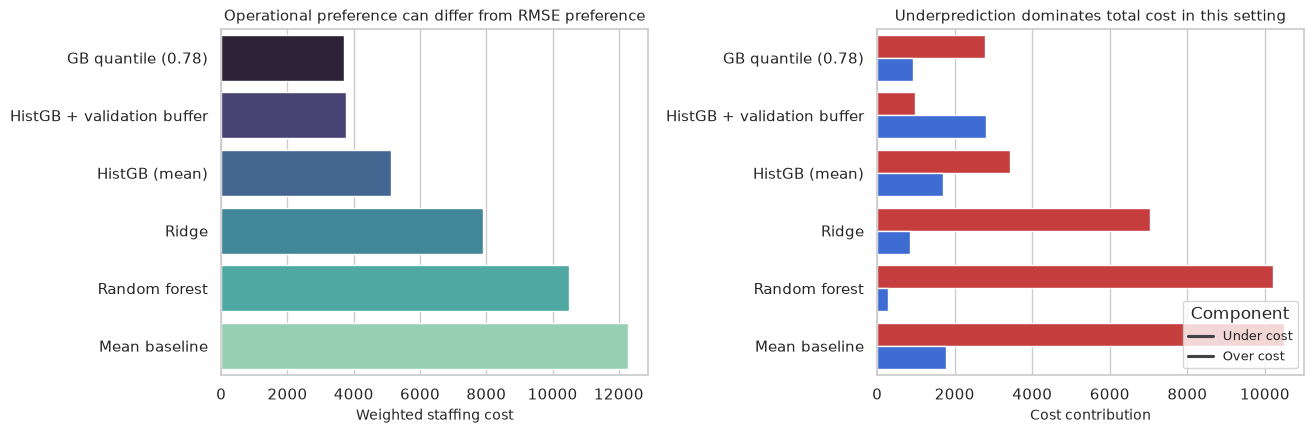

In [9]:
# Section focus: 5. Translating Error into Operational Cost.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


fig, axes = plt.subplots(1, 2, figsize=(13.3, 4.5))

cost_long = cost_table.melt(
    id_vars='model',
    value_vars=['under_cost_component', 'over_cost_component'],
    var_name='component',
    value_name='cost',
)

sns.barplot(data=cost_table, y='model', x='weighted_cost', palette='mako', ax=axes[0])
axes[0].set_title('Operational preference can differ from RMSE preference')
axes[0].set_xlabel('Weighted staffing cost')
axes[0].set_ylabel('')

sns.barplot(
    data=cost_long,
    y='model',
    x='cost',
    hue='component',
    orient='h',
    palette=['#dc2626', '#2563eb'],
    ax=axes[1],
)
axes[1].set_title('Underprediction dominates total cost in this setting')
axes[1].set_xlabel('Cost contribution')
axes[1].set_ylabel('')
axes[1].legend(title='Component', labels=['Under cost', 'Over cost'], loc='lower right')

plt.tight_layout()


The practical question in Translating Error into Operational Cost is simple. What would this result make the analyst do differently?


,validation_buffer,raw_mean_rmse,buffered_rmse,raw_mean_weighted_cost,buffered_weighted_cost,quantile_weighted_cost,best_test_only_offset,best_test_only_cost
0,8.788,23.007,25.929,"5,133.539","3,769.145","3,697.127",7.500,"3,735.656"


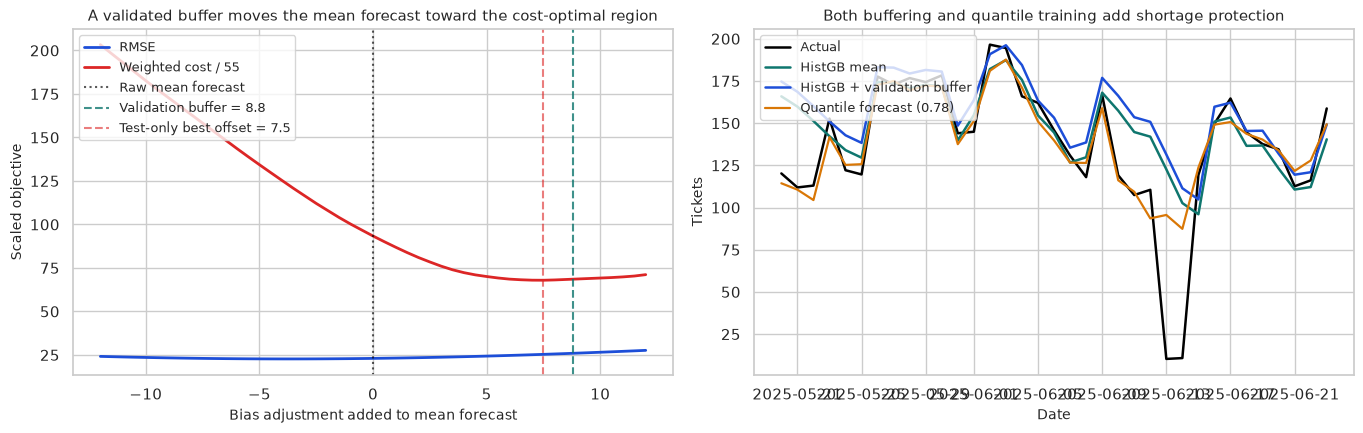

In [10]:
# Section focus: 5. Translating Error into Operational Cost.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


# Compare a mean-oriented forecast with practical and idealized upward adjustments.
quantile_model_name = 'GB quantile (0.78)'
quantile_pred_test = predictions[quantile_model_name]['test']

offset_grid = np.linspace(-12, 12, 49)
curve_rows = []
for offset in offset_grid:
    shifted_pred = mean_pred_test + offset
    curve_rows.append({
        'offset': offset,
        'rmse': np.sqrt(mean_squared_error(y_test, shifted_pred)),
        'weighted_cost': operational_cost(y_test, shifted_pred, under_cost=under_cost, over_cost=over_cost)['weighted_cost'],
    })
curve_table = pd.DataFrame(curve_rows)

best_rmse_row = curve_table.loc[curve_table['rmse'].idxmin()]
best_cost_row = curve_table.loc[curve_table['weighted_cost'].idxmin()]
validated_buffer_cost = operational_cost(y_test, buffered_mean_test, under_cost=under_cost, over_cost=over_cost)['weighted_cost']
validated_buffer_rmse = np.sqrt(mean_squared_error(y_test, buffered_mean_test))

comparison_window = diagnostics[['date', 'tickets_next_day']].copy()
comparison_window['HistGB_mean'] = mean_pred_test
comparison_window['HistGB_buffered'] = buffered_mean_test
comparison_window['Quantile_forecast'] = quantile_pred_test
comparison_window = comparison_window.tail(35)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.5))

axes[0].plot(curve_table['offset'], curve_table['rmse'], color='#1d4ed8', linewidth=2, label='RMSE')
axes[0].plot(curve_table['offset'], curve_table['weighted_cost'] / 55, color='#dc2626', linewidth=2, label='Weighted cost / 55')
axes[0].axvline(0, linestyle=':', color='black', alpha=0.65, label='Raw mean forecast')
axes[0].axvline(validation_buffer, linestyle='--', color='#0f766e', alpha=0.80, label=f'Validation buffer = {validation_buffer:.1f}')
axes[0].axvline(best_cost_row['offset'], linestyle='--', color='#dc2626', alpha=0.60, label=f'Test-only best offset = {best_cost_row["offset"]:.1f}')
axes[0].set_title('A validated buffer moves the mean forecast toward the cost-optimal region')
axes[0].set_xlabel('Bias adjustment added to mean forecast')
axes[0].set_ylabel('Scaled objective')
axes[0].legend(loc='upper left')

axes[1].plot(comparison_window['date'], comparison_window['tickets_next_day'], color='black', linewidth=1.8, label='Actual')
axes[1].plot(comparison_window['date'], comparison_window['HistGB_mean'], color='#0f766e', linewidth=1.8, label='HistGB mean')
axes[1].plot(comparison_window['date'], comparison_window['HistGB_buffered'], color='#1d4ed8', linewidth=1.8, label='HistGB + validation buffer')
axes[1].plot(comparison_window['date'], comparison_window['Quantile_forecast'], color='#d97706', linewidth=1.6, label='Quantile forecast (0.78)')
axes[1].set_title('Both buffering and quantile training add shortage protection')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Tickets')
axes[1].legend(loc='upper left')

plt.tight_layout()

pd.DataFrame({
    'validation_buffer': [validation_buffer],
    'raw_mean_rmse': [mean_squared_error(y_test, mean_pred_test) ** 0.5],
    'buffered_rmse': [validated_buffer_rmse],
    'raw_mean_weighted_cost': [operational_cost(y_test, mean_pred_test, under_cost=under_cost, over_cost=over_cost)['weighted_cost']],
    'buffered_weighted_cost': [validated_buffer_cost],
    'quantile_weighted_cost': [operational_cost(y_test, quantile_pred_test, under_cost=under_cost, over_cost=over_cost)['weighted_cost']],
    'best_test_only_offset': [best_cost_row['offset']],
    'best_test_only_cost': [best_cost_row['weighted_cost']],
})


Use the Translating Error into Operational Cost output to decide what the analysis should do next. This output earns attention when it changes the workflow rather than merely adding detail.


### Discussion of the Cost Layer

The cost table now shows a more realistic decision story. A very conservative model such as `Ridge` can sometimes look acceptable under a simple linear cost function only because it overpredicts broadly and persistently. That deployment strategy is expensive in excess capacity and operationally blunt.

The more instructive comparison is between the strong nonlinear mean forecast and disciplined shortage protection layered on top of it. In this notebook, a **validation-chosen service buffer** substantially reduces weighted cost relative to the raw mean forecast, although it does so by accepting a noticeable RMSE penalty. The **quantile forecast** moves in the same direction from a more principled modeling angle and, in this rerun, achieves the best overall balance between predictive accuracy and shortage protection.

That is a good practical lesson. When decisions punish shortage more than excess, use raw RMSE rankings as one input rather than the whole decision rule. Start from a strong predictive model, then either add a validated buffer or train for an asymmetric objective that matches the business loss.


## 6. Practical Checklist

| Question | Why it matters |
|---|---|
| What downstream action uses the prediction? | The action determines which forecast errors are truly costly |
| Are large misses more harmful than typical misses? | That pushes you toward RMSE or tail-sensitive diagnostics |
| Are actual values sometimes very small? | Then MAPE can become unstable or misleading |
| Do residuals change by regime, segment, or time period? | Aggregate scores may hide operational blind spots |
| Is underprediction more expensive than overprediction? | Consider asymmetric loss or quantile-oriented forecasts |
| Does the best RMSE model also minimize business cost? | Often it does not |
| Are you reporting both average fit and failure modes? | Stakeholders need both summary and structure |

A mature regression-evaluation workflow almost never ends with one scalar metric. It combines a few aligned summary measures, regime-specific residual checks, and an explicit decision-loss view.


## Wrap-Up

This notebook reframed regression evaluation as a decision problem. We compared standard metrics such as MAE, RMSE, median absolute error, WAPE, sMAPE, and MAPE, then used residual diagnostics to reveal where average scores were hiding structure. In the synthetic staffing example, release periods and low-volume holiday days behaved very differently, and percentage errors became especially unstable in the low-volume regime.

The operational-cost section then made the broader lesson concrete. Once underprediction became much more expensive than overprediction, the preferred strategy shifted away from the raw mean forecast. A validation-chosen service buffer and a quantile-oriented forecast both improved shortage protection, illustrating how evaluation should be aligned to action rather than treated as a generic scoreboard.

## References

- Hyndman, R. J., & Koehler, A. B. (2006). *Another look at measures of forecast accuracy.* *International Journal of Forecasting, 22*(4), 679-688. [https://doi.org/10.1016/j.ijforecast.2006.03.001](https://doi.org/10.1016/j.ijforecast.2006.03.001)
- Chai, T., & Draxler, R. R. (2014). *Root mean square error (RMSE) or mean absolute error (MAE)? Arguments against avoiding RMSE in the literature.* *Geoscientific Model Development, 7*(3), 1247-1250. [https://doi.org/10.5194/gmd-7-1247-2014](https://doi.org/10.5194/gmd-7-1247-2014)
- Hodson, T. O. (2022). *Root-mean-square error (RMSE) or mean absolute error (MAE): when to use them or not.* *Geoscientific Model Development, 15*(14), 5481-5487. [https://doi.org/10.5194/gmd-15-5481-2022](https://doi.org/10.5194/gmd-15-5481-2022)
- Tofallis, C. (2015). *A better measure of relative prediction accuracy for model selection and model estimation.* *Journal of the Operational Research Society, 66*(8), 1352-1362. [https://doi.org/10.1057/jors.2014.103](https://doi.org/10.1057/jors.2014.103)
- Barrow, D. K., & Crone, S. F. (2016). *A comparison of AdaBoost algorithms for time series forecast combination.* *International Journal of Forecasting, 32*(4), 1103-1119. [https://doi.org/10.1016/j.ijforecast.2016.01.006](https://doi.org/10.1016/j.ijforecast.2016.01.006)
- Koenker, R., & Bassett, G. W. (1978). *Regression Quantiles.* *Econometrica, 46*(1), 33-50. [https://doi.org/10.2307/1913643](https://doi.org/10.2307/1913643)
